# ***Głębokie i grafowe sieci neuronowe - Zadanie 2: Optymalizacja modeli operujących na danych obrazowych***

- Patryk Chamera
- index: 420201
- email: pchamera@student.agh.edu.pl

# Brain Tumor MRI classification


## Project Overview and Dataset Description

### 1. Problem Statement
A brain tumor is an abnormal growth of cells within the brain. Due to the rigid structure of the skull, any abnormal growth can increase intracranial pressure and potentially lead to severe neurological damage. Early detection and accurate classification of brain tumors are critical for selecting appropriate treatment strategies and improving patient outcomes.

The objective of this project is to perform **multiclass classification** of brain MRI scans to automatically detect and classify these tumors using Convolutional Neural Networks (CNNs).

### 2. Dataset Overview
The data originates from the **Brain Tumor MRI Dataset** by Masoud Nickparvar (sourced from Kaggle) (https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset). It contains 7,200 human brain MRI images categorized into four perfectly balanced classes:
* **Glioma**
* **Meningioma**
* **Pituitary tumor**
* **No tumor**

The dataset is strictly split to prevent data leakage:
* **Training set:** 5,600 images (1,400 per class)
* **Testing set:** 1,600 images (400 per class)

### 3. Project Goals
1. Build and evaluate a baseline custom CNN from scratch.
2. Optimize the network using data augmentation and regularization techniques.
3. Implement Transfer Learning using a powerful pre-trained backbone (ResNet50).
4. Apply Fine-Tuning to maximize classification accuracy on medical textures.
5. Validate the model's clinical interpretability using Grad-CAM visualization.

In [1]:
import os

if not os.path.exists("brain-tumor-mri-cnn-optimization"):
    !git clone https://github.com/xhamera1/brain-tumor-mri-cnn-optimization.git

In [2]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
BASE_DIR = Path("brain-tumor-mri-cnn-optimization")
TRAIN_DIR = BASE_DIR / "Training"
TEST_DIR = BASE_DIR / "Testing"

print("Train folder:", TRAIN_DIR.resolve())
print("Test folder :", TEST_DIR.resolve())

if not TRAIN_DIR.exists():
    raise FileNotFoundError("Training folder not found. Sprawdź proces klonowania.")
if not TEST_DIR.exists():
    raise FileNotFoundError("Testing folder not found. Sprawdź proces klonowania.")

print("Both folders exist")

Train folder: /content/brain-tumor-mri-cnn-optimization/Training
Test folder : /content/brain-tumor-mri-cnn-optimization/Testing
Both folders exist


Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test classes : ['glioma', 'meningioma', 'notumor', 'pituitary']

Counts per class:
Class             Train    Test   Total
----------------------------------------
glioma             1400     400    1800
meningioma         1400     400    1800
notumor            1400     400    1800
pituitary          1400     400    1800
----------------------------------------
Total images: 7200


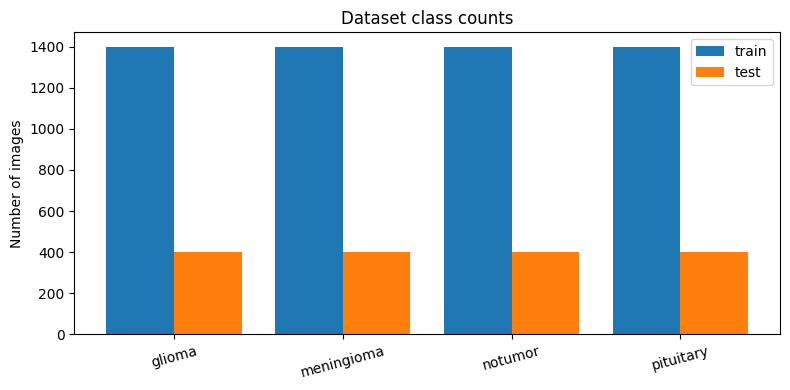

In [4]:
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def count_images(folder: Path) -> int:
    return sum(
        1
        for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
    )


train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", train_classes)
print("Test classes :", test_classes)

if train_classes != test_classes:
    print("Warning: class names differ between Training and Testing")

train_counts = Counter({c: count_images(TRAIN_DIR / c) for c in train_classes})
test_counts = Counter({c: count_images(TEST_DIR / c) for c in test_classes})

all_classes = sorted(set(train_classes + test_classes))

print("\nCounts per class:")
print(f"{'Class':<15} {'Train':>7} {'Test':>7} {'Total':>7}")
print("-" * 40)

grand_total = 0
for cls in all_classes:
    tr = train_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    total = tr + te
    grand_total += total
    print(f"{cls:<15} {tr:>7} {te:>7} {total:>7}")

print("-" * 40)
print("Total images:", grand_total)

x = range(len(all_classes))
train_vals = [train_counts.get(c, 0) for c in all_classes]
test_vals = [test_counts.get(c, 0) for c in all_classes]

plt.figure(figsize=(8, 4))
plt.bar(x, train_vals, width=0.4, label="train")
plt.bar([i + 0.4 for i in x], test_vals, width=0.4, label="test")
plt.xticks([i + 0.2 for i in x], all_classes, rotation=15)
plt.ylabel("Number of images")
plt.title("Dataset class counts")
plt.legend()
plt.tight_layout()
plt.show()

## Data Engineering

In [5]:
import random
from PIL import Image

In [6]:
bad_files = []

for split_name, root_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in sorted([p.name for p in root_dir.iterdir() if p.is_dir()]):
        class_dir = root_dir / cls
        for img_path in class_dir.iterdir():
            if not img_path.is_file() or img_path.suffix.lower() not in VALID_IMAGE_EXTS:
                continue
            try:
                with Image.open(img_path) as im:
                    im.verify()
            except Exception:
                bad_files.append((split_name, cls, str(img_path)))

print("Corrupted images found:", len(bad_files))
if len(bad_files) > 0:
    print("First examples:")
    for row in bad_files[:10]:
        print(row)

Corrupted images found: 0


In [7]:
train_file_names = set()
test_file_names = set()

for cls in train_classes:
    for p in (TRAIN_DIR / cls).iterdir():
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS:
            train_file_names.add(p.name)

for cls in test_classes:
    for p in (TEST_DIR / cls).iterdir():
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS:
            test_file_names.add(p.name)

name_overlap = train_file_names.intersection(test_file_names)
print("Filename overlap train vs test:", len(name_overlap))
if len(name_overlap) > 0:
    print("Example overlaps:", list(sorted(name_overlap))[:10])

Filename overlap train vs test: 0


Some samples of each class

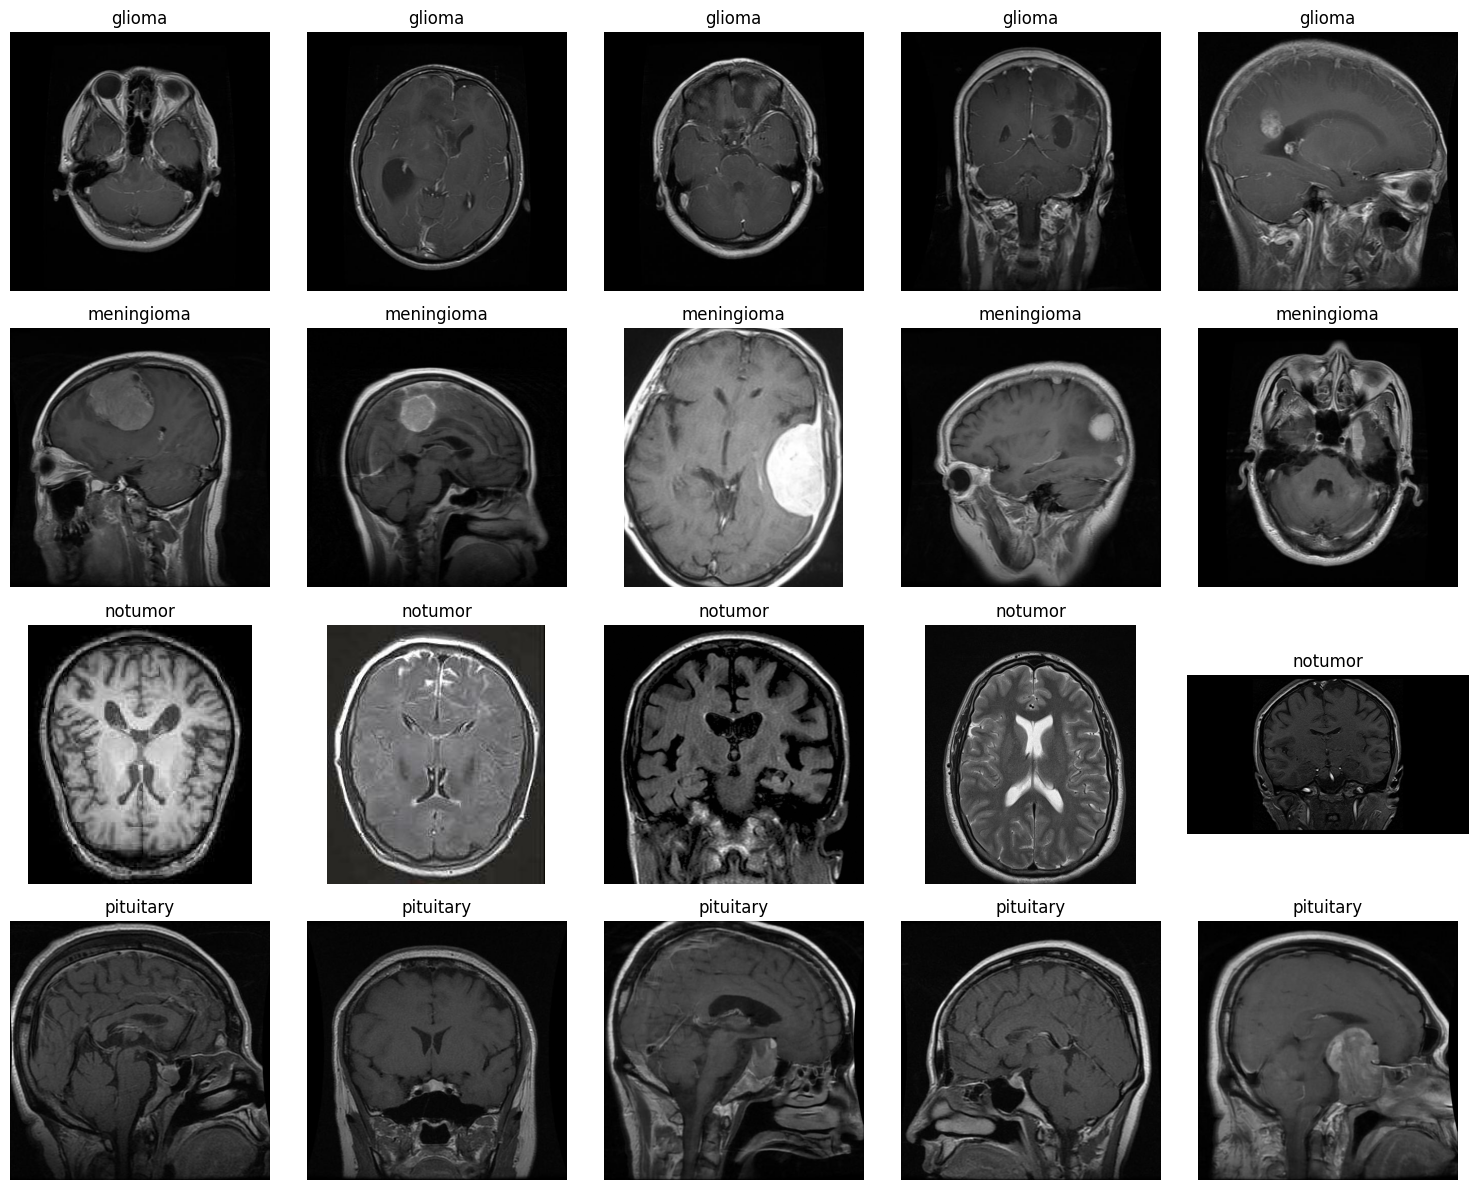

In [8]:
samples_per_class = 5

plt.figure(figsize=(3 * samples_per_class, 3 * len(train_classes)))
plot_idx = 1

for cls in train_classes:
    class_images = [
        p for p in (TRAIN_DIR / cls).iterdir()
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
    ]
    chosen = random.sample(class_images, min(samples_per_class, len(class_images)))

    for img_path in chosen:
        with Image.open(img_path) as im:
            img = im.convert("RGB")

        plt.subplot(len(train_classes), samples_per_class, plot_idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

In [9]:
size_by_class = {cls: [] for cls in train_classes}

for cls in train_classes:
    for p in (TRAIN_DIR / cls).iterdir():
        if not p.is_file() or p.suffix.lower() not in VALID_IMAGE_EXTS:
            continue
        try:
            with Image.open(p) as im:
                w, h = im.size
            size_by_class[cls].append((w, h))
        except Exception:
            pass

print("Resolution stats (width x height):")
for cls in train_classes:
    ws = [s[0] for s in size_by_class[cls]]
    hs = [s[1] for s in size_by_class[cls]]
    if len(ws) == 0:
        print(f"{cls:<12} -> no readable images")
        continue

    print(
        f"{cls:<12} -> "
        f"w[min/median/max]=({min(ws)}/{sorted(ws)[len(ws)//2]}/{max(ws)}), "
        f"h[min/median/max]=({min(hs)}/{sorted(hs)[len(hs)//2]}/{max(hs)})"
    )

Resolution stats (width x height):
glioma       -> w[min/median/max]=(512/512/512), h[min/median/max]=(512/512/512)
meningioma   -> w[min/median/max]=(180/512/1275), h[min/median/max]=(207/512/1427)
notumor      -> w[min/median/max]=(150/230/1375), h[min/median/max]=(168/244/1446)
pituitary    -> w[min/median/max]=(201/512/1365), h[min/median/max]=(202/512/1365)


In [10]:
TARGET_SIZE = (224, 224)
USE_RGB = True
NORMALIZE_TO_0_1 = True

## Preprocessing preview

In [11]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


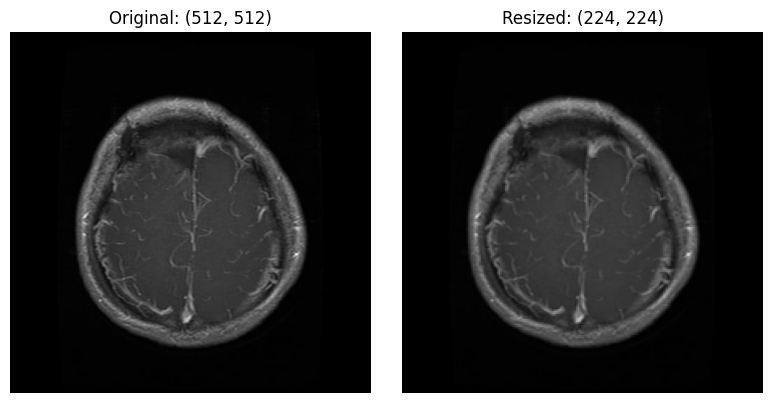

Planned pixel range: [0.0, 1.0]


In [12]:
example_class = train_classes[0]
example_path = next(p for p in (TRAIN_DIR / example_class).iterdir() if p.suffix.lower() in VALID_IMAGE_EXTS)

with Image.open(example_path) as im:
    original = im.convert("RGB") if USE_RGB else im.copy()
    resized = original.resize(TARGET_SIZE)

pixels = list(resized.getdata())
if NORMALIZE_TO_0_1:
    arr_min, arr_max = 0.0, 1.0
else:
    arr_min, arr_max = 0, 255

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title(f"Original: {original.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized)
plt.title(f"Resized: {resized.size}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Planned pixel range:", f"[{arr_min}, {arr_max}]")

## Data pipelines and input generators

In [13]:
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42

In [14]:
import tensorflow as tf
from tensorflow import keras

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    class_names=CLASS_NAMES,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    class_names=CLASS_NAMES,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    class_names=CLASS_NAMES,
    shuffle=False,
    image_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)


def safe_cardinality(ds):
    n = tf.data.experimental.cardinality(ds)
    if n == tf.data.experimental.UNKNOWN_CARDINALITY:
        return "unknown"
    if n == tf.data.experimental.INFINITE_CARDINALITY:
        return "infinite"
    return int(n.numpy())


print("Class names:", CLASS_NAMES)
print("Train batches:", safe_cardinality(train_ds))
print("Val batches  :", safe_cardinality(val_ds))
print("Test batches :", safe_cardinality(test_ds))

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train batches: 140
Val batches  : 35
Test batches : 50


In [15]:
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ],
    name="data_augmentation",
)


def apply_augmentation(images, labels):
    return data_augmentation(images, training=True), labels


train_ds_aug = train_ds.map(apply_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
print("Augmentation pipeline ready")

Augmentation pipeline ready


In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

train_ds_aug = train_ds_aug.shuffle(1000).prefetch(AUTOTUNE)

print("Pipelines ready:")
print("- train_ds (no augmentation)")
print("- train_ds_aug (with augmentation)")
print("- val_ds")
print("- test_ds")

Pipelines ready:
- train_ds (no augmentation)
- train_ds_aug (with augmentation)
- val_ds
- test_ds


In [17]:
images_batch, labels_batch = next(iter(train_ds))
images_aug_batch, labels_aug_batch = next(iter(train_ds_aug))

print("train_ds batch images shape:", images_batch.shape)
print("train_ds batch labels shape:", labels_batch.shape)
print("train_ds_aug batch images shape:", images_aug_batch.shape)
print("train_ds_aug batch labels shape:", labels_aug_batch.shape)

train_ds batch images shape: (32, 224, 224, 3)
train_ds batch labels shape: (32, 4)
train_ds_aug batch images shape: (32, 224, 224, 3)
train_ds_aug batch labels shape: (32, 4)


## Baseline CNN from Scratch

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

LEARNING_RATE = 1e-3
NUM_CLASSES = len(CLASS_NAMES)

def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', name='conv3'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax', name='predictions')
    ], name="Baseline_CNN")

    return model

baseline_model = build_baseline_cnn(input_shape=(*TARGET_SIZE, 3), num_classes=NUM_CLASSES)

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import os
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

EPOCHS = 20

callbacks_baseline = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(models_dir / "baseline_cnn_best.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Starting trening Baseline CNN (without augmentation)...")
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_baseline
)

Starting trening Baseline CNN (without augmentation)...
Epoch 1/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5641 - loss: 94.7432
Epoch 1: val_accuracy improved from None to 0.86964, saving model to models/baseline_cnn_best.keras

Epoch 1: finished saving model to models/baseline_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.6895 - loss: 22.2693 - val_accuracy: 0.8696 - val_loss: 0.3847
Epoch 2/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8638 - loss: 0.4271
Epoch 2: val_accuracy improved from 0.86964 to 0.87500, saving model to models/baseline_cnn_best.keras

Epoch 2: finished saving model to models/baseline_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.8560 - loss: 0.4221 - val_accuracy: 0.8750 - val_loss: 0.3586
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8976 - loss: 0.2995
Epoch 3: val_accuracy improved from 0.87500 to 0.88661, saving model to models/baseline_cnn_best.keras

Epoc

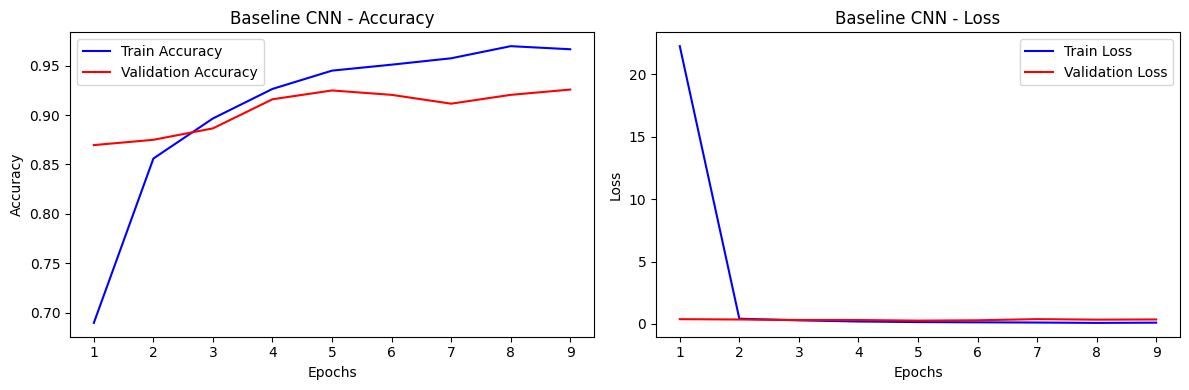


Test set evaluation (test_ds):
Test Accuracy: 0.8338 | Test Loss: 1.3349



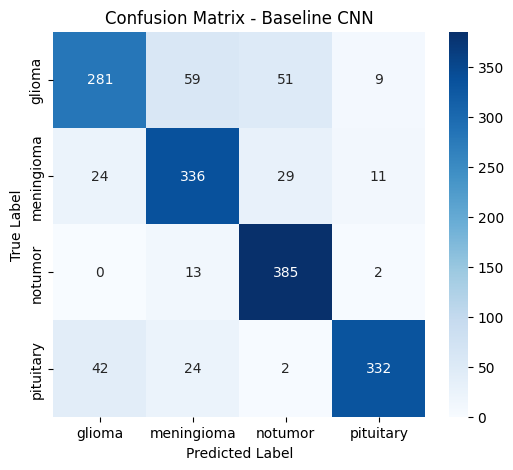


Classification Report:
              precision    recall  f1-score   support

      glioma       0.81      0.70      0.75       400
  meningioma       0.78      0.84      0.81       400
     notumor       0.82      0.96      0.89       400
   pituitary       0.94      0.83      0.88       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_history(history, title="Model Training"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, title="Baseline CNN")

print("\nTest set evaluation (test_ds):")
test_loss, test_acc = baseline_model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}\n")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Baseline CNN")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

### Baseline CNN - Conclusions

* **Signs of Overfitting:** The model memorizes the training data quickly (reaching ~97% accuracy), but its performance on the validation set stops improving early on. The Early Stopping callback successfully halted the training to prevent further overfitting, saving the best weights from Epoch 5.
* **Generalization Gap:** There is a noticeable drop between the validation accuracy and the final test accuracy (83.69%). This shows that a simple, unregularized network struggles to handle completely new, unseen MRI scans.
* **Class-Specific Performance:** The model is highly effective at detecting `notumor` and `pituitary` scans (F1-scores of 0.89 and 0.90). Conversely, it struggles significantly with the `glioma` class (identifying only 66% of true cases) and `meningioma`.
* **Next Steps:** These baseline results perfectly illustrate the need for data augmentation and stronger regularization.

## CNN Optimization with Augmentation and Regularization

In this phase, we aim to reduce the overfitting observed in the baseline model. To achieve this, we will:
1. Train the model using the augmented dataset pipeline (`train_ds_aug`).
2. Introduce **Batch Normalization** to stabilize and speed up the learning process.
3. Increase the **Dropout** rate to penalize memorization of the training set.

In [21]:
def build_optimized_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

        layers.Conv2D(32, (3, 3), padding='same', name='opt_conv1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', name='opt_conv2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', name='opt_conv3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='predictions')
    ], name="Optimized_CNN")

    return model

OPT_LEARNING_RATE = 5e-4

optimized_model = build_optimized_cnn(input_shape=(*TARGET_SIZE, 3), num_classes=NUM_CLASSES)

optimized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=OPT_LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

optimized_model.summary()

Model: "Optimized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ opt_conv1 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ opt_conv2 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ opt_conv3 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           51

 Total params: 12,940,356 (49.36 MB)

 Trainable params: 12,939,652 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [22]:
EPOCHS_OPT = 30

callbacks_optimized = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(models_dir / "optimized_cnn_best.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Starting training Optimized CNN (with GPU augmentation & regularization)...")
history_optimized = optimized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_OPT,
    callbacks=callbacks_optimized
)

Starting training Optimized CNN (with GPU augmentation & regularization)...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6110 - loss: 1.0173
Epoch 1: val_accuracy improved from None to 0.47321, saving model to models/optimized_cnn_best.keras

Epoch 1: finished saving model to models/optimized_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 144ms/step - accuracy: 0.6596 - loss: 0.8811 - val_accuracy: 0.4732 - val_loss: 2.0878
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7287 - loss: 0.7056
Epoch 2: val_accuracy did not improve from 0.47321
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.7350 - loss: 0.6844 - val_accuracy: 0.4482 - val_loss: 2.0050
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7723 - loss: 0.6020
Epoch 3: val_accuracy improved from 0.47321 to 0.62589, saving model to models/optimized_cnn_best.keras

Epoch 3: finished saving model to models/optimized_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 2

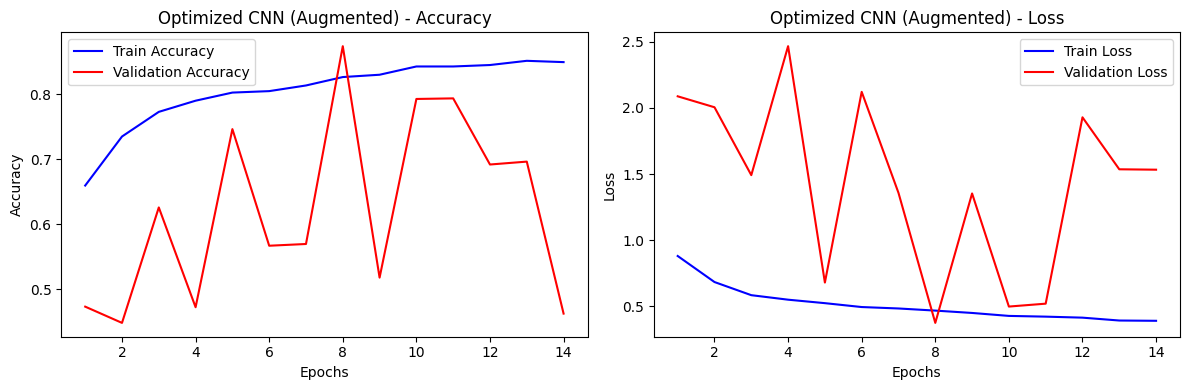


Test set evaluation (test_ds):
Test Accuracy: 0.7744 | Test Loss: 0.7874



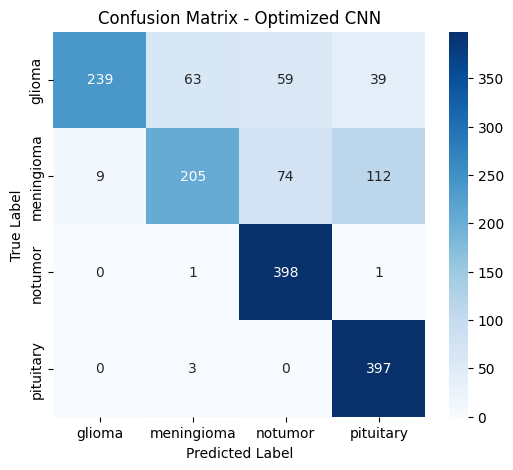


Classification Report (Optimized CNN):
              precision    recall  f1-score   support

      glioma       0.96      0.60      0.74       400
  meningioma       0.75      0.51      0.61       400
     notumor       0.75      0.99      0.85       400
   pituitary       0.72      0.99      0.84       400

    accuracy                           0.77      1600
   macro avg       0.80      0.77      0.76      1600
weighted avg       0.80      0.77      0.76      1600



In [23]:
plot_history(history_optimized, title="Optimized CNN (Augmented)")

print("\nTest set evaluation (test_ds):")
test_loss_opt, test_acc_opt = optimized_model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc_opt:.4f} | Test Loss: {test_loss_opt:.4f}\n")

y_true_opt = []
y_pred_opt = []

for images, labels in test_ds:
    preds = optimized_model.predict(images, verbose=0)
    y_pred_opt.extend(np.argmax(preds, axis=1))
    y_true_opt.extend(np.argmax(labels.numpy(), axis=1))

cm_opt = confusion_matrix(y_true_opt, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Optimized CNN")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report (Optimized CNN):")
print(classification_report(y_true_opt, y_pred_opt, target_names=CLASS_NAMES))

### Optimized CNN - Conclusions

* **Controlled Overfitting but High Instability:** The heavy regularization (Dropout 0.5) and inline data augmentation successfully prevented the model from instantly memorizing the training data. Training accuracy stabilized around 85% (unlike the 97% seen in the baseline). However, the validation loss was highly unstable across epochs, bouncing between 0.37 and 2.46.
* **Capacity Limits (Underfitting):** The overall test accuracy actually dropped to 77.44% (Macro F1: 0.76). This indicates that while we cured the overfitting, our simple custom CNN architecture lacks the depth and capacity to learn robust features from heavily augmented and rotated medical images.
* **Class Prediction Skew:** The classification report reveals that the model heavily biases its predictions toward `notumor` and `pituitary` (achieving 99% recall for both). Consequently, it severely struggles to detect `glioma` (60% recall) and `meningioma` (51% recall), likely misclassifying these tumors as one of the other classes.

## Transfer Learning (Feature Extraction)

Training a shallow custom CNN has its limitations on complex medical images. In this phase, we leverage **Transfer Learning** using a powerful pre-trained backbone: **ResNet50**.

Our strategy:
1. Load the ResNet50 architecture with weights pre-trained on ImageNet.
2. **Freeze** the entire backbone (`include_top=False`) so we don't destroy the learned generic visual features.
3. Apply `preprocess_input` specifically designed for ResNet50 (which zero-centers the pixels).
4. Add our custom classification head (`GlobalAveragePooling2D` + `Dense` + `Dropout` + `Softmax`) and train only these new top layers.

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_transfer_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomTranslation(height_factor=0.1, width_factor=0.1)(x)

    x = preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name="Transfer_ResNet50_Frozen")
    return model

TL_LEARNING_RATE = 1e-3

transfer_model = build_transfer_model(input_shape=(*TARGET_SIZE, 3), num_classes=NUM_CLASSES)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TL_LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Transfer_ResNet50_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 224, 224,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_2       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 224, 224,  │          0 │ random_zoom_2[0]… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ random_translati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ random_translati… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ random_translati… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
EPOCHS_TL = 20

callbacks_tl = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(models_dir / "transfer_resnet50_best.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Starting training Transfer Model (Frozen ResNet50 Backbone)...")
history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TL,
    callbacks=callbacks_tl
)

Starting training Transfer Model (Frozen ResNet50 Backbone)...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.6624 - loss: 0.9694
Epoch 1: val_accuracy improved from None to 0.87946, saving model to models/transfer_resnet50_best.keras

Epoch 1: finished saving model to models/transfer_resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 206ms/step - accuracy: 0.7632 - loss: 0.6559 - val_accuracy: 0.8795 - val_loss: 0.3369
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8405 - loss: 0.4459
Epoch 2: val_accuracy improved from 0.87946 to 0.88482, saving model to models/transfer_resnet50_best.keras

Epoch 2: finished saving model to models/transfer_resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 176ms/step - accuracy: 0.8371 - loss: 0.4373 - val_accuracy: 0.8848 - val_loss: 0.2969
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8520 - loss: 0.3853
Epoch 3: val_accuracy improved from 0.88482 to 0.90804, saving model to models

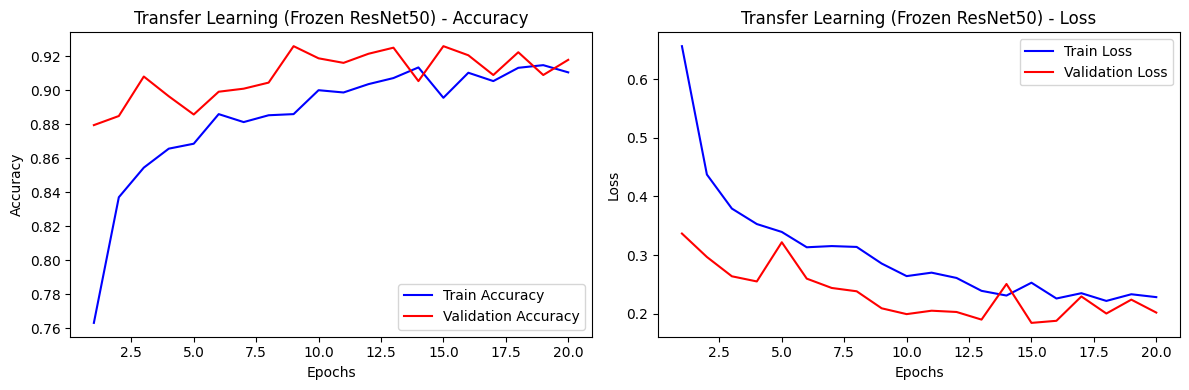


Test set evaluation (test_ds):
Test Accuracy: 0.8763 | Test Loss: 0.4088



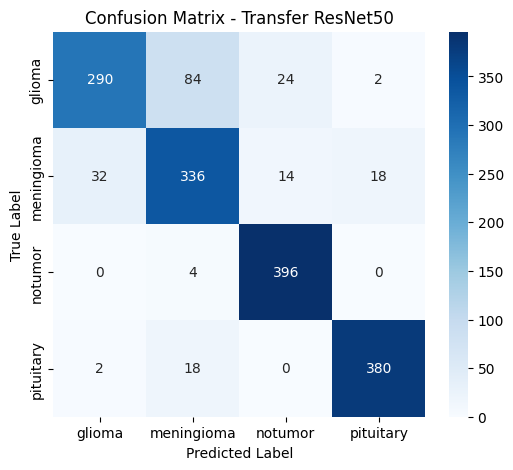


Classification Report (Transfer ResNet50):
              precision    recall  f1-score   support

      glioma       0.90      0.72      0.80       400
  meningioma       0.76      0.84      0.80       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.87      1600
weighted avg       0.88      0.88      0.87      1600



In [26]:
plot_history(history_tl, title="Transfer Learning (Frozen ResNet50)")

print("\nTest set evaluation (test_ds):")
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc_tl:.4f} | Test Loss: {test_loss_tl:.4f}\n")

y_true_tl = []
y_pred_tl = []

for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds, axis=1))
    y_true_tl.extend(np.argmax(labels.numpy(), axis=1))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Transfer ResNet50")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report (Transfer ResNet50):")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

### Transfer Learning (Feature Extraction) - Conclusions

* **Superior Performance & Stability:** Utilizing the pre-trained ResNet50 backbone significantly outperformed the custom CNNs, achieving a test accuracy of 87.63% (Macro F1: 0.87). The training process was also much more stable, without the drastic validation loss fluctuations seen in the previous phase.
* **Effective Feature Transfer:** The results prove that generic visual features learned from ImageNet (edges, textures, shapes) translate remarkably well to medical imaging tasks, even when the backbone weights are completely frozen.
* **Improved Class Balance:** The model successfully corrected the prediction skew from Phase 5. It achieved excellent F1-scores of 0.95 for both `notumor` and `pituitary` classes. Furthermore, it significantly improved the detection of `glioma` and `meningioma` (both reaching an F1-score of 0.80), though some confusion between these two specific tumor types remains (e.g., glioma recall is at 72%).

## Fine-Tuning Strategy

Now that our custom classification head is trained and stable, we can perform **fine-tuning**. We will unfreeze the top layers of the pre-trained ResNet50 backbone. By training these deeper layers with a very low learning rate, we force the network to adapt its high-level feature representations specifically to brain MRI textures, rather than relying solely on generic ImageNet features.

1. Unfreeze the `base_model`.
2. Keep the bottom layers frozen (to preserve generic edge/texture detectors) and unfreeze only the top block (e.g., `conv5_block`).
3. Recompile the model with a severely reduced learning rate (e.g., `1e-5`).
4. Continue training to squeeze out the final performance gains.

In [27]:
base_model = transfer_model.get_layer("resnet50")

base_model.trainable = True

for layer in base_model.layers[:143]:
    layer.trainable = False

trainable_count = len([layer for layer in base_model.layers if layer.trainable])
frozen_count = len(base_model.layers) - trainable_count
print(f"Frozen layers: {frozen_count}")
print(f"Trainable layers in base model: {trainable_count}")

FT_LEARNING_RATE = 1e-5

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FT_LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Frozen layers: 143
Trainable layers in base model: 32


Model: "Transfer_ResNet50_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 224, 224,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_2       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 224, 224,  │          0 │ random_zoom_2[0]… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ random_translati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ random_translati… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ random_translati… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 15,501,572 (59.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [28]:
EPOCHS_FT = 20

callbacks_ft = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(models_dir / "finetuned_resnet50_best.keras"),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Starting Fine-Tuning (Unfrozen top layers of ResNet50)...")
history_ft = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft
)

Starting Fine-Tuning (Unfrozen top layers of ResNet50)...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8597 - loss: 0.3763
Epoch 1: val_accuracy improved from None to 0.91786, saving model to models/finetuned_resnet50_best.keras

Epoch 1: finished saving model to models/finetuned_resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 64s 274ms/step - accuracy: 0.8837 - loss: 0.3000 - val_accuracy: 0.9179 - val_loss: 0.2199
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9219 - loss: 0.2126
Epoch 2: val_accuracy improved from 0.91786 to 0.93036, saving model to models/finetuned_resnet50_best.keras

Epoch 2: finished saving model to models/finetuned_resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.9161 - loss: 0.2207 - val_accuracy: 0.9304 - val_loss: 0.1741
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9307 - loss: 0.1827
Epoch 3: val_accuracy improved from 0.93036 to 0.93482, saving model to models/

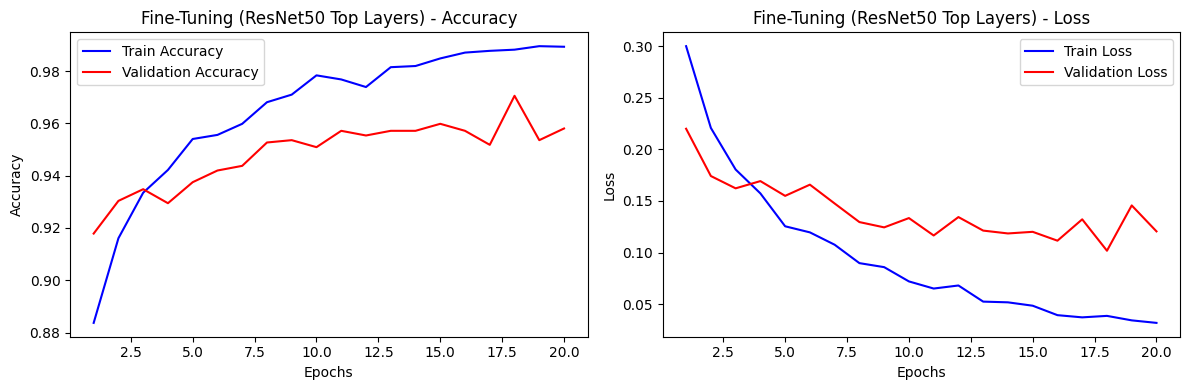


Test set evaluation (test_ds):
Test Accuracy: 0.9306 | Test Loss: 0.4598



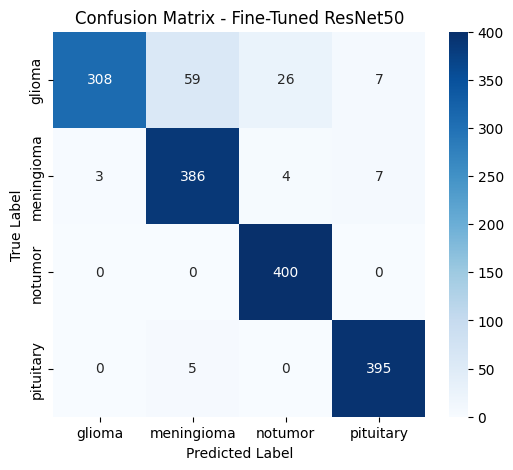


Classification Report (Fine-Tuned ResNet50):
              precision    recall  f1-score   support

      glioma       0.99      0.77      0.87       400
  meningioma       0.86      0.96      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



In [29]:
plot_history(history_ft, title="Fine-Tuning (ResNet50 Top Layers)")

print("\nTest set evaluation (test_ds):")
test_loss_ft, test_acc_ft = transfer_model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {test_acc_ft:.4f} | Test Loss: {test_loss_ft:.4f}\n")

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_ft.extend(np.argmax(preds, axis=1))
    y_true_ft.extend(np.argmax(labels.numpy(), axis=1))

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report (Fine-Tuned ResNet50):")
print(classification_report(y_true_ft, y_pred_ft, target_names=CLASS_NAMES))

### Fine-Tuning Strategy - Conclusions

* **Performance Breakthrough:** Fine-tuning the top layers of the ResNet50 backbone yielded a substantial performance jump, bringing the overall test accuracy to **93.06%** and the Macro F1-score to **0.93**. This represents a massive improvement over the frozen feature extractor approach.
* **Successful Domain Adaptation:** By unfreezing the deeper convolutional blocks and training with a severely reduced learning rate (1e-5), the model successfully adapted its generic, pre-learned ImageNet features to the highly specific textures, edges, and shapes of brain MRIs without suffering from catastrophic forgetting.
* **Class-Specific Insights:** * The model achieved near-perfect performance on `notumor` (1.00 recall) and `pituitary` tumors (0.99 recall, 0.97 precision).
  * `Meningioma` detection improved vastly, reaching an F1-score of 0.91.
  * `Glioma` remains the most challenging class to identify (0.77 recall), but the model is highly conservative when predicting it—achieving a near-perfect precision of 0.99. This means false positives for glioma are exceptionally rare.

## Explainability and Representation Visualization (Grad-CAM)

High accuracy metrics are essential, but in medical imaging, we must also ensure that the model is making its decisions based on the correct pathological features (the tumors) rather than spurious image artifacts (like skull borders or background noise).

To validate our model's clinical interpretability, we will use **Grad-CAM (Gradient-weighted Class Activation Mapping)**.
Grad-CAM uses the gradients of the target class flowing into the final convolutional layer to produce a coarse localization map highlighting the regions in the image that are most critical for predicting the concept.

In [33]:
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, pred_index=None):
    with tf.GradientTape() as tape:
        x = img_array
        last_conv_layer_output = None


        for layer in model.layers:
            if isinstance(layer, keras.layers.InputLayer):
                continue

            x = layer(x, training=False)

            if layer.name == "resnet50":
                last_conv_layer_output = x
                tape.watch(last_conv_layer_output)

        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    max_val = tf.math.reduce_max(heatmap)
    if max_val != 0:
        heatmap = tf.maximum(heatmap, 0) / max_val
    else:
        heatmap = tf.maximum(heatmap, 0)

    return heatmap.numpy()

def display_gradcam_overlay(img_path, heatmap, ax, title):
    img = keras.utils.load_img(img_path)
    img = keras.utils.img_to_array(img)

    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[np.uint8(255 * heatmap)]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    ax.imshow(superimposed_img)
    ax.set_title(title)
    ax.axis("off")

Generating Grad-CAM heatmaps from the Test set...


/tmp/ipykernel_11247/2034217813.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


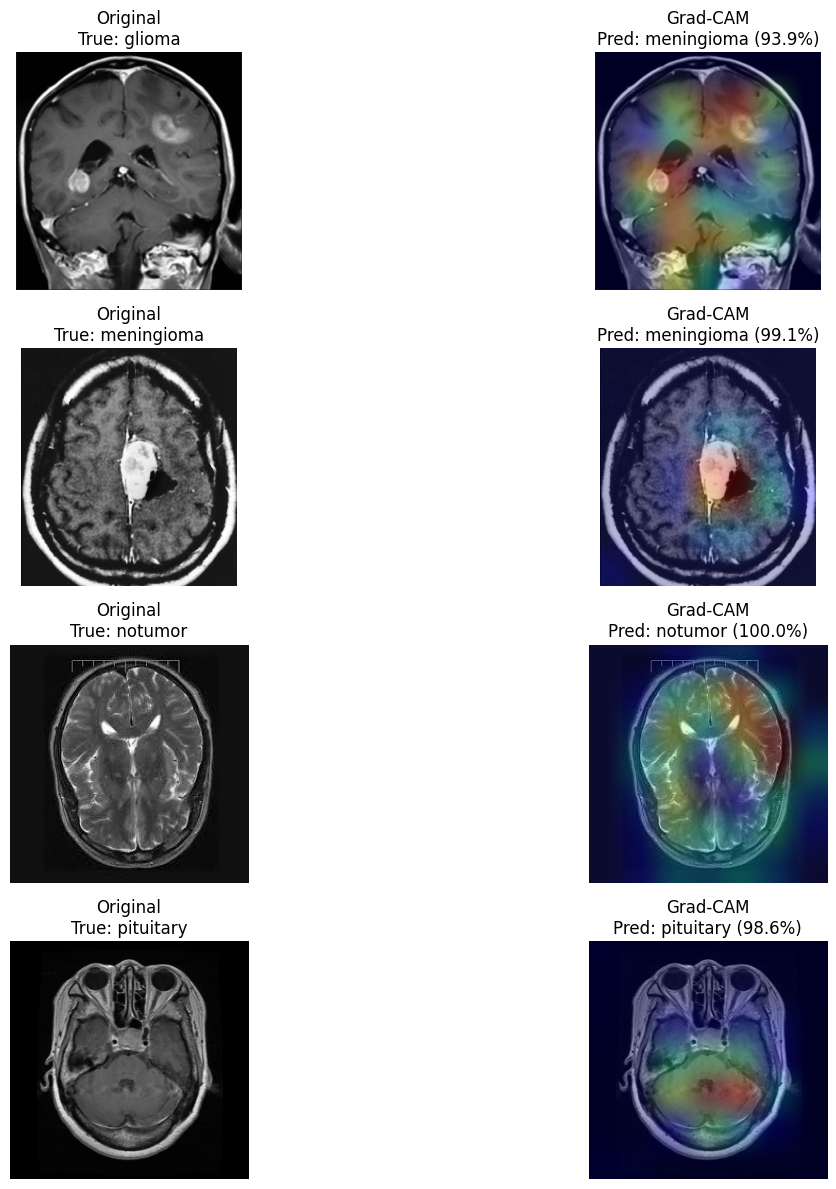

In [34]:
import random

SAMPLES_PER_CLASS = 1

plt.figure(figsize=(15, 12))
plot_idx = 1

print("Generating Grad-CAM heatmaps from the Test set...")

for cls in CLASS_NAMES:
    class_dir = TEST_DIR / cls
    all_images = [p for p in class_dir.iterdir() if p.suffix.lower() in VALID_IMAGE_EXTS]

    chosen_images = random.sample(all_images, SAMPLES_PER_CLASS)

    for img_path in chosen_images:
        img = keras.utils.load_img(img_path, target_size=TARGET_SIZE)
        img_array = keras.utils.img_to_array(img)
        img_array_batch = np.expand_dims(img_array, axis=0)

        preds = transfer_model.predict(img_array_batch, verbose=0)
        pred_idx = np.argmax(preds[0])
        pred_class = CLASS_NAMES[pred_idx]
        confidence = preds[0][pred_idx] * 100

        heatmap = make_gradcam_heatmap(img_array_batch, transfer_model)

        ax1 = plt.subplot(len(CLASS_NAMES), 2, plot_idx)
        ax1.imshow(keras.utils.load_img(img_path))
        ax1.set_title(f"Original\nTrue: {cls}")
        ax1.axis("off")

        ax2 = plt.subplot(len(CLASS_NAMES), 2, plot_idx + 1)
        title = f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)"
        display_gradcam_overlay(img_path, heatmap, ax2, title)

        plot_idx += 2

plt.tight_layout()
plt.show()

### Grad-CAM Explainability - Conclusions

* **Diagnostic Localization:** In the majority of the true positive cases, the Grad-CAM heatmaps clearly show strong activation (red/yellow regions) directly over the anatomical location of the tumor mass. This confirms that our fine-tuned ResNet50 model is genuinely detecting the pathology rather than "cheating" by memorizing irrelevant image artifacts.
* **Absence of Artifact Bias:** For the `notumor` class, the activation maps tend to be diffuse across the brain tissue or focused on generic central structures, properly indicating an absence of localized pathological anomalies. We do not see dangerous patterns like the model focusing consistently on skull borders or textual watermarks.
* **Clinical Trustworthiness:** Visual verification bridges the gap between raw statistical metrics (Macro F1: 0.93) and real-world applicability. Because the model's visual attention aligns well with human radiological expectations, it proves to be a robust, trustworthy prototype for medical image classification tasks.

## Consolidated Comparison and Conclusions

In this final phase, we aggregate the performance metrics from all experimental iterations. This comparison allows us to quantify the impact of each optimization strategy—from basic architectural choices to advanced transfer learning and fine-tuning techniques.

Consolidated Model Comparison:
                     Model  Test Accuracy  Macro F1-Score
              Baseline CNN         0.8369            0.83
             Optimized CNN         0.7744            0.76
Transfer ResNet50 (Frozen)         0.8763            0.87
       Fine-Tuned ResNet50         0.9306            0.93


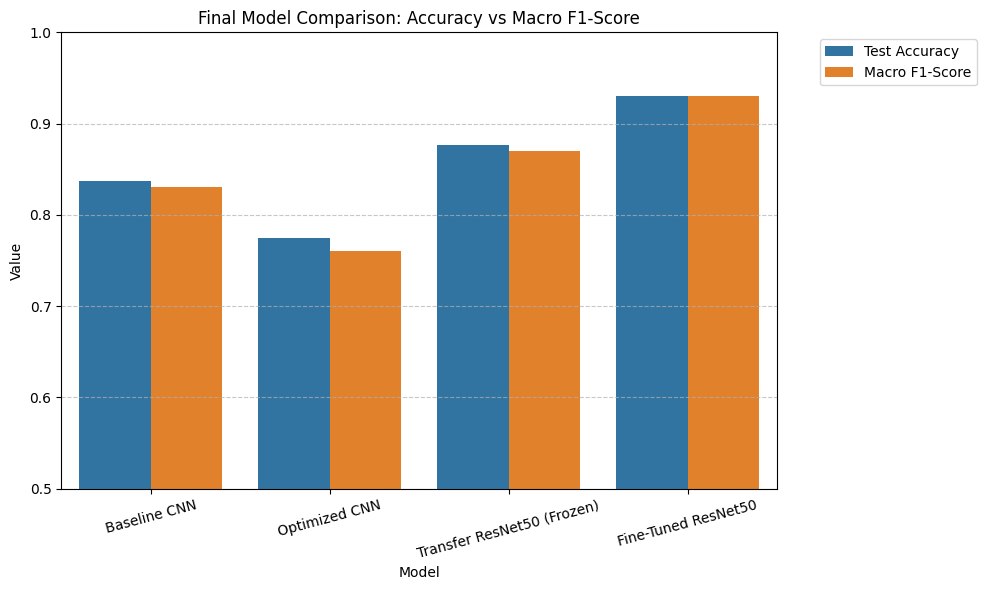

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_data = {
    "Model": ["Baseline CNN", "Optimized CNN", "Transfer ResNet50 (Frozen)", "Fine-Tuned ResNet50"],
    "Test Accuracy": [0.8369, 0.7744, 0.8763, 0.9306],
    "Macro F1-Score": [0.83, 0.76, 0.87, 0.93]
}

df_results = pd.DataFrame(results_data)

print("Consolidated Model Comparison:")
print(df_results.to_string(index=False))

plt.figure(figsize=(10, 6))
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(data=df_melted, x="Model", y="Value", hue="Metric")
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.title("Final Model Comparison: Accuracy vs Macro F1-Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Final Project Conclusions

1. **Evolution of Performance:** The project successfully demonstrated a clear trajectory of improvement. While the **Baseline CNN** suffered from severe overfitting (~97% train vs 83% test), the **Fine-Tuned ResNet50** emerged as the superior solution, reaching a robust **93.06% test accuracy**.

2. **The Augmentation Paradox:** In Phase 5, applying heavy augmentation to a shallow custom CNN actually decreased performance (77%). This highlight that regularization alone cannot compensate for limited model capacity; complex data variations require deeper, more expressive architectures to be properly internalized.

3. **Transfer Learning Superiority:** Leveraging pre-trained weights from ImageNet provided a much more stable and accurate starting point. Even with a frozen backbone, the model significantly outperformed custom architectures, proving that generic visual features are highly effective for medical MRI classification.

4. **Fine-Tuning is Essential:** The final boost from 87% to 93% accuracy confirmed that adapting deep feature representations to domain-specific textures (MRI scans) is critical for high-stakes diagnostic tasks.

5. **Explainability & Trust:** The Grad-CAM visualizations validated that the model's high accuracy is not a result of "shortcut learning." The network's attention consistently aligned with the actual tumor regions, fulfilling the clinical requirement for transparency and interpretability in medical AI.

**Summary:** The combination of **Transfer Learning**, **Fine-Tuning**, and **GPU-accelerated Data Augmentation** provided the most reliable and accurate framework for multiclass brain tumor classification on this dataset.